In [1]:
import numpy as np
import h5py
from scipy.ndimage import zoom, laplace, gaussian_filter
import matplotlib.pyplot as plt
# import matplotlib
# matplotlib.use('Agg')
import multiprocessing as mp
import os
from tqdm import tqdm
import json
import traceback
import pydicom
# Test if gdcm works for decompressing JPEG 2000
print("IT IS {}, GDCM IS LOCKED AND LOADED".format(pydicom.pixel_data_handlers.gdcm_handler.is_available()))
import shutil
from skimage import feature
import pickle

IT IS True, GDCM IS LOCKED AND LOADED


In [2]:
ORGAN = 'abdominal'
# Threshold for air
THRESH = 0.05
# Shrink factor for pseudo segmentation
SHRINK = 6

In [3]:
""" DATA """
INH5 = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/data/abdominal-4dflow-uncorr-ecc.hdf5'
data = h5py.File(INH5,'r')
ALLMETA = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/data/abdominal-4dflow-meta.pkl'
INTERMEDIATE_PATH = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/data/abdominal-downsampled_data.hdf5'
PREDICTIONS = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_raw_predictions_revs.hdf5'.format(ORGAN)
ARTERYSPATH = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_arterys_uploads'.format(ORGAN)
ZIPPEDPATH = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_zipped'.format(ORGAN)
ALLPATHS = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/data/abdominal-4dflow-paths.json'
DIMS = 64
T=20
OUTH5vol = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_volumetric_training_{}pct_thresh_revs.hdf5'.format(ORGAN, int(THRESH*100))
OUTH5coeff = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_coeff_training_{}pct_thresh_revs.hdf5'.format(ORGAN, int(THRESH*100))
outvol = h5py.File(OUTH5vol, 'r')
outcoeff = h5py.File(OUTH5coeff, 'r')
outpred = h5py.File(PREDICTIONS, 'r')
with open(ALLMETA, 'rb') as meta_file:
    allmeta = pickle.load(meta_file)
with open(ALLPATHS) as paths_file:
    allpaths = json.load(paths_file)

In [4]:
"""
OUR POST-PROCESSING PIPELINE WILL BE AS FOLLOWS (BROKEN INTO 2 PARTS):
PART 1: Data resizing
0) Load test case 64x64x64 volumes
1) Back-calculate the original dimensions and cropped overhang for each case, recover VENC
2) Calculate coefficients (in parallel) for cubic polynomial and keep the median value over time
3) Regenerate (in parallel) the full-volume (with overhang), rescale by the VENC
4) Calculate corrected volumes (in series) via summation of uncorrected and delta, save as int16
5) Save to disk

PART 2: Data saving to DICOM
0) Load filepaths json and saved cnn-corrected volumes
1) Make new directory to save DICOMs to
2) For each case, iterate through all paths looking for 4d flow typed DICOMS
3) From json, figure out if we flip over slice axis via 'sign' field (-1 means we do)
4) If sign < 0, flip corrected volume over slice dim
5) From each DICOM figure out instance number, reverse engineer slice (now reformatted) and time
6) Edit DICOM, replacing pixel values with corrected values, being mindful to change to int16 and compressing if necessary
7) Save and upload to Arterys
"""
testkeys = list(outpred.keys())

In [5]:
""" CALCULATE COEFFICIENTS """
downsampled = h5py.File(INTERMEDIATE_PATH, 'r')

# Let's make life easy and assume consistent 64x64x64x20x3
DIMS = 64
NCOEFFS = 20
# Calculate once and re-use
r, c, s = np.meshgrid(np.arange(0,DIMS),np.arange(0,DIMS),np.arange(0,DIMS), indexing='ij')
r = r.astype(np.float64)
c = c.astype(np.float64)
s = s.astype(np.float64)
x = np.zeros((DIMS*DIMS*DIMS, NCOEFFS), dtype=np.float64)
x[:,0] = np.ravel( r**3 )
x[:,1] = np.ravel( c**3 )
x[:,2] = np.ravel( s**3 )
x[:,3] = np.ravel( c*r**2 )
x[:,4] = np.ravel( s*r**2 )
x[:,5] = np.ravel( r*c**2 )
x[:,6] = np.ravel( s*c**2 )
x[:,7] = np.ravel( r*s**2 )
x[:,8] = np.ravel( c*s**2 )
x[:,9] = np.ravel( r*c*s )
x[:,10] = np.ravel( r**2 )
x[:,11] = np.ravel( c**2 )
x[:,12] = np.ravel( s**2 )
x[:,13] = np.ravel( r*c )
x[:,14] = np.ravel( r*s )
x[:,15] = np.ravel( c*s )
x[:,16] = np.ravel( r )
x[:,17] = np.ravel( c )
x[:,18] = np.ravel( s )
x[:,19] = np.ravel( 1 )

# Unfortunately, need to pre-load data to use MP
allmag = dict()
alldelta_cnn = dict()
all_params = dict()
for k in tqdm(testkeys):
    allmag[k] = downsampled[k+'_uncorr'][...,0]
    alldelta_cnn[k] = outpred[k]
    all_params[k] = allmeta[k]

# Function assumes a ECC volumetric timeseries with 3 components is passed as input, solves for coefficients at each
# timepoint, and treats median as ground truth.  Fitlers out low-magnitude (air) values based on mag data.
# Uses key as input to permit use of multiprocessing
def calc_coeffs(k):
    DIMS = 64
    T = 20
    linmag = np.ravel(np.mean(np.copy(allmag[k]), axis=-1)) #<--Use the mean of mag to find air
    
    maskedpix = np.ones(linmag.shape)
    maskedpix[linmag < THRESH] = 0
    maskedpix = np.reshape(maskedpix, (DIMS,DIMS,DIMS))
    mask_ = gaussian_filter(maskedpix, sigma=3)
    mask_[mask_ > 0.333] = 1
    mask_[mask_ < 1] = 0
    
    mask_s = zoom(mask_, ( (DIMS-2*SHRINK)/DIMS, (DIMS-2*SHRINK)/DIMS, (DIMS-2*SHRINK)/DIMS ), order=1)
    mask_s[mask_s > 0.5] = 1
    mask_s[mask_s < 1] = 0
    maskedpix = np.zeros((DIMS,DIMS,DIMS))
    maskedpix[SHRINK:-SHRINK,SHRINK:-SHRINK,SHRINK:-SHRINK] = mask_s
    linmaskedpix = np.ravel(maskedpix)
    keep = np.argwhere(linmaskedpix > 0)
    
    x_all = np.zeros((T, NCOEFFS, 3), dtype=np.float64)
    for t in range(T):
        for comp in range(3):
            all_y = np.ravel(np.copy(alldelta_cnn[k][:,:,:,t,comp])).astype(np.float64)
            filtered_y = np.squeeze(all_y[keep])
            y = np.expand_dims(filtered_y, axis=-1)
            x_ = np.zeros((len(filtered_y), NCOEFFS), dtype=np.float64)
            x_origin = np.copy(x).astype(np.float64)
            for n in range(NCOEFFS):
                temp = x_origin[:,n]
                x_[:,n] = np.squeeze(temp[keep]).astype(np.float64)
            m = np.matmul(np.matmul(np.linalg.pinv(np.matmul(x_.T, x_)), x_.T), y).astype(np.float64)
            x_all[t,:,comp]  = np.squeeze(m)
    x_median = np.squeeze(np.median(x_all, axis=0))
    return x_median, maskedpix
    
# Function assumes a set of N_COEFFSx3 coefficients
def generate_delta_cubic(incoeffs, k):
    incoeffs = incoeffs.astype(np.float64)
    DOWNDIMS = 64
    T = 20
    # Retrieve parameters for successful resizing
    CROP = 0.1 # Crop for abdominal
    venc = all_params[k]['venc']
    rowpad = all_params[k]['rows_pad']
    colpad = all_params[k]['columns_pad']
    rownpy = all_params[k]['rows_npy']
    colnpy = all_params[k]['columns_npy']
    slicenpy = all_params[k]['slices_npy']
    rowcrop = int(rownpy * CROP)
    colcrop = int(colnpy * CROP)
    slicecrop = int(slicenpy * CROP)
    # Whether to flip along slice dim to be compatible with instance number
    flipflag = all_params[k]['sign']
    # The cropped overhang will dictate additional steps outside the range (0-64), but stepsize is dictated by
    # the ratio of DIMS:(unpadded fullresolution size - 2*crop) <-- not interchangeable with 80% due to rounding
    # Stepsize < 1; number of steps outside bounds equals cropsize * stepsize 
    ss_r = float(DOWNDIMS / (rownpy - 2*rowcrop))
    r_overhang = rowcrop * ss_r
    r_start = -r_overhang
    r_end = DOWNDIMS + r_overhang
    
    ss_c = float(DOWNDIMS / (colnpy - 2*colcrop))
    c_overhang = colcrop * ss_c
    c_start = -c_overhang
    c_end = DOWNDIMS + c_overhang
    
    ss_s = float(DOWNDIMS / (slicenpy - 2*slicecrop))
    s_overhang = slicecrop * ss_s
    s_start = -s_overhang
    s_end = DOWNDIMS + s_overhang
    # Use linspace here instead of arange to be strict about number of steps.  Need to set endpoint as false to mirror [0:N) indexing
    r2, c2, s2 = np.meshgrid(np.linspace(r_start,r_end,num=rownpy,endpoint=False),np.linspace(c_start,c_end,num=colnpy,endpoint=False),np.linspace(s_start,s_end,num=slicenpy,endpoint=False), indexing='ij')
    r2 = r2.astype(np.float64)
    c2 = c2.astype(np.float64)
    s2 = s2.astype(np.float64)
    x2 = np.zeros((int(rownpy*colnpy*slicenpy), NCOEFFS), dtype=np.float64)
    x2[:,0] = np.ravel( r2**3 )
    x2[:,1] = np.ravel( c2**3 )
    x2[:,2] = np.ravel( s2**3 )
    x2[:,3] = np.ravel( c2*r2**2 )
    x2[:,4] = np.ravel( s2*r2**2 )
    x2[:,5] = np.ravel( r2*c2**2 )
    x2[:,6] = np.ravel( s2*c2**2 )
    x2[:,7] = np.ravel( r2*s2**2 )
    x2[:,8] = np.ravel( c2*s2**2 )
    x2[:,9] = np.ravel( r2*c2*s2 )
    x2[:,10] = np.ravel( r2**2 )
    x2[:,11] = np.ravel( c2**2 )
    x2[:,12] = np.ravel( s2**2 )
    x2[:,13] = np.ravel( r2*c2 )
    x2[:,14] = np.ravel( r2*s2 )
    x2[:,15] = np.ravel( c2*s2 )
    x2[:,16] = np.ravel( r2 )
    x2[:,17] = np.ravel( c2 )
    x2[:,18] = np.ravel( s2 )
    x2[:,19] = np.ravel( 1 )
    x_mult = (np.copy(x2).T).astype(np.float64) #<-- x is N x N_COEFFS, need it to be N_COEFFS x N
    output = np.zeros((rownpy,colnpy,slicenpy,3), dtype=np.float64)
    for comp in range(3):
        coeff = incoeffs[:,comp]
        coeff = np.reshape(coeff, (1, NCOEFFS))
        product = np.matmul(coeff, x_mult)
        product = np.reshape(product, (rownpy,colnpy,slicenpy))
        output[...,comp] = product
    """ Hande partial phase FOV zeropadding """
    repadded = np.pad(output, ((rowpad,rowpad),(colpad,colpad),(0,0),(0,0)), mode='constant', constant_values=0)
    """ Flip along slice axis iff necessary """
    if flipflag < 0:
        repadded = np.flip(repadded, axis=2)
    """ Scale by VENC """
    corrected_delta = repadded * venc
    return corrected_delta

# Master function compatible with multiprocessing which first obtains the necessary dimensions and VENC for each PID and
# subsequently regenerates a single-timepoint volume of the best (median) approximation of the ECC delta.  This is added to
# the uncorrected data and returned for intermediate saving
def construct_corrected_volumes(k):
    print(k)
    curr_coeffs, maskedpix = calc_coeffs(k)
    delta = generate_delta_cubic(curr_coeffs,k)
    return (delta, curr_coeffs, maskedpix)

100%|██████████| 48/48 [00:01<00:00, 24.52it/s]


In [6]:
# if __name__ == "__main__":
#     pool = mp.Pool()
#     all_deltas = pool.map(construct_corrected_volumes, testkeys[0:4])
#     pool.close()
#     pool.join()
# For some reason, multiprocessing is bugged here and matrices do not add correctly probably due to shared memory
all_deltas = []
for k in tqdm(testkeys):
    all_deltas.append(construct_corrected_volumes(k))

  0%|          | 0/48 [00:00<?, ?it/s]

Adichig


  2%|▏         | 1/48 [00:09<07:23,  9.44s/it]

Biradrack


  4%|▍         | 2/48 [00:18<07:12,  9.39s/it]

...

 96%|█████████▌| 46/48 [06:59<00:18,  9.07s/it]

Ticaco


 98%|█████████▊| 47/48 [07:09<00:09,  9.27s/it]

Tupudsub


100%|██████████| 48/48 [07:18<00:00,  9.14s/it]


<IPython.core.display.Javascript object>


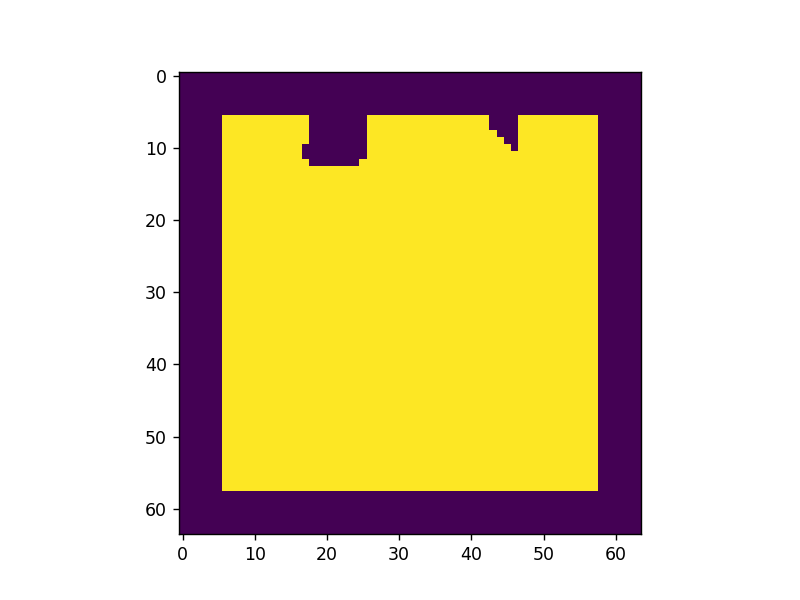

In [7]:
%matplotlib notebook
plt.figure()
plt.imshow(all_deltas[0][2][:,:,32])

# plt.imshow(alldelta_cnn['Basanu'][:,:,32,0,1])

In [8]:
""" RUN QC """

""" SAVE DELTA RESULTS TO HDF5 """
try:
    os.remove('/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_processed_cnn_corrected_revs.hdf5'.format(ORGAN))
except:
    pass
cnncorrh5 = h5py.File('/media/evmasuta/bigchonk/Abdominal-ECC-Net/{}_processed_cnn_corrected_revs.hdf5'.format(ORGAN), 'w')

tidx = 0
QC_DIR = '/media/evmasuta/bigchonk/Abdominal-ECC-Net/postprocessing_qc/'
count = 0
for k in tqdm(testkeys):
    plt.figure(figsize=(6,14))
    regressed = all_deltas[count][0].astype(np.int16)
    print(all_deltas[count][1])
    mask = all_deltas[count][2]
    # Can use compression since other dataset is compressed.  int16 to save space, will be converted anyway downstream
    cnncorr_arr = np.copy(data[k+'_uncorrected'][...,1:]) # Remove mag idx
    for time in range(T):
        cnncorr_arr[:,:,:,time,:] += regressed
    cnncorr_arr = cnncorr_arr.astype(np.int16)
    cnncorrh5.create_dataset(k, data=cnncorr_arr, dtype=np.int16, compression='lzf')

    sidx = regressed.shape[2] // 2
    V_ecc = all_params[k]['venc'] * 0.05
    V_vel = all_params[k]['venc'] * 0.05
    
    # Plot regressed first, then manual
    ax1 = plt.subplot(731)
    ax1.imshow(regressed[:,:,sidx,0], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax1.axis('off')
    ax1.set_title('CNN. Vx')
    
    ax2 = plt.subplot(732)
    ax2.imshow(regressed[:,:,sidx,1], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax2.axis('off')
    ax2.set_title('CNN. Vy')
    
    ax3 = plt.subplot(733)
    ax3.imshow(regressed[:,:,sidx,2], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax3.axis('off')
    ax3.set_title('CNN. Vz')
    
    ax4 = plt.subplot(734)
    ax4.imshow(data[k+'_ecc'][:,:,sidx,tidx,0]-data[k+'_uncorrected'][:,:,sidx,tidx,1], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax4.axis('off')
    ax4.set_title('Man. Vx')
    
    ax5 = plt.subplot(735)
    ax5.imshow(data[k+'_ecc'][:,:,sidx,tidx,1]-data[k+'_uncorrected'][:,:,sidx,tidx,2], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax5.axis('off')
    ax5.set_title('Man. Vy')
    
    ax6 = plt.subplot(736)
    ax6.imshow(data[k+'_ecc'][:,:,sidx,tidx,2]-data[k+'_uncorrected'][:,:,sidx,tidx,3], cmap='jet', vmin=-V_ecc, vmax=V_ecc)
    ax6.axis('off')
    ax6.set_title('Man. Vz')
    
    # Now plot what the components looks like post correction
    # Plot regressed first, then manual
    V = 0.05
    ax7 = plt.subplot(737)
    ax7.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,1] + regressed[:,:,sidx,0], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax7.axis('off')
    ax7.set_title('Reg. Corr. Vx')
    
    ax8 = plt.subplot(738)
    ax8.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,2] + regressed[:,:,sidx,1], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax8.axis('off')
    ax8.set_title('Reg. Corr. Vy')
    
    ax9 = plt.subplot(739)
    ax9.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,3] + regressed[:,:,sidx,2], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax9.axis('off')
    ax9.set_title('Reg. Corr. Vz')
    
    ax10 = plt.subplot(7,3,10)
    ax10.imshow(data[k+'_ecc'][:,:,sidx,tidx,0], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax10.axis('off')
    ax10.set_title('Man. Corr. Vx')
    
    ax11 = plt.subplot(7,3,11)
    ax11.imshow(data[k+'_ecc'][:,:,sidx,tidx,1], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax11.axis('off')
    ax11.set_title('Man. Corr. Vy')
    
    ax12 = plt.subplot(7,3,12)
    ax12.imshow(data[k+'_ecc'][:,:,sidx,tidx,2], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax12.axis('off')
    ax12.set_title('Man. Corr. Vz')
    
    ax13 = plt.subplot(7,3,13)
    ax13.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,1], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax13.axis('off')
    ax13.set_title('Uncorr. Vx')
    
    ax14 = plt.subplot(7,3,14)
    ax14.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,2], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax14.axis('off')
    ax14.set_title('Uncorr. Vy')

    ax15 = plt.subplot(7,3,15)
    ax15.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,3], cmap='bwr', vmin=-V_vel, vmax=V_vel)
    ax15.axis('off')
    ax15.set_title('Uncorr. Vz')
    
    ax16 = plt.subplot(7,3,16)
    ax16.imshow(data[k+'_uncorrected'][:,:,sidx,tidx,0], cmap='gray')
    ax16.axis('off')
    ax16.set_title('Mag')
    
    ax17 = plt.subplot(7,3,17)
    ax17.imshow(mask[:,:,32], cmap='gray', vmin=0, vmax=1)
    ax17.axis('off')
    ax17.set_title('Laplace')
    
    mask[mask < 1] = np.nan
    masked = mask[:,:,32] * downsampled[k+'_uncorr'][:,:,32,tidx,0]
    ax18 = plt.subplot(7,3,18)
    ax18.imshow(masked, cmap='gray', vmin=0, vmax=1)
    ax18.axis('off')
    ax18.set_title('Used Pix Mag')
    
    nanmask = mask[:,:,32]
    nanmask[nanmask > 0] = 1
    nanmask[nanmask < 0] = np.nan
    
    ax19 = plt.subplot(7,3,19)
    ax19.imshow(nanmask * downsampled[k+'_ecc'][:,:,32,tidx,0], cmap='jet')
    ax19.axis('off')
    ax19.set_title('Used Pix Vx')
    
    ax20 = plt.subplot(7,3,20)
    ax20.imshow(nanmask * downsampled[k+'_ecc'][:,:,32,tidx,1], cmap='jet')
    ax20.axis('off')
    ax20.set_title('Used Pix Vy')
    
    ax21 = plt.subplot(7,3,21)
    ax21.imshow(nanmask * downsampled[k+'_ecc'][:,:,32,tidx,2], cmap='jet')
    ax21.axis('off')
    ax21.set_title('Used Pix Vz')
    
    plt.tight_layout()
    plt.savefig(QC_DIR + k + '{}pct_thresh.png'.format(int(THRESH*100)))
    plt.close()
    count += 1

  0%|          | 0/48 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

[[ 2.90229029e-07  6.63718825e-08  8.84230642e-07]
 [-7.50439490e-07 -2.61764102e-08 -1.36786670e-07]
 [ 2.70279533e-08  3.14274719e-07 -3.90495502e-07]
 [ 5.20132204e-07 -7.09932407e-07  3.57950338e-07]
 [ 3.89725609e-07 -1.02027780e-06  3.23879715e-07]
 [-2.17726288e-07 -4.96458787e-08 -2.45220979e-07]
 [-8.24420450e-08  8.26460310e-07 -2.94226885e-07]
 [ 9.75259524e-08  1.50979372e-07 -3.01875023e-07]
 [-1.42010926e-06  7.87562156e-07 -1.77456841e-07]
 [-7.50247896e-08  5.04818643e-08 -5.23309501e-07]
 [-7.22420714e-05  4.30162852e-05 -1.06943158e-04]
 [ 8.55329195e-05 -7.58557928e-06  1.99709587e-05]
 [ 4.18689813e-05 -5.70865386e-05  5.04048231e-05]
 [ 3.93903114e-05  2.76847969e-05 -1.59560923e-05]
 [-3.87887259e-05 -7.30658598e-05  1.05313118e-04]
 [ 9.85462255e-05 -1.08341936e-04  4.76554396e-05]
 [ 2.18453047e-04  3.72434772e-04  1.68140012e-03]
 [-7.83253379e-04 -5.60793972e-05 -1.01742717e-04]
 [-2.59459851e-03  5.35264233e-03 -4.81226341e-03]
 [ 6.12636172e-03 -6.04707095e-

  2%|▏         | 1/48 [00:18<14:25, 18.41s/it]

<IPython.core.display.Javascript object>

...

[[-1.78437965e-09  2.82048495e-08  2.44372367e-07]
 [-1.61481442e-07  1.10198241e-08 -7.33663411e-08]
 [ 3.07704970e-07  1.85098760e-07 -2.60830020e-07]
 [ 1.08561647e-06 -2.76224283e-07  2.66106672e-07]
 [-2.54524560e-07 -1.18350155e-06  2.42011725e-07]
 [-9.62844061e-08 -7.85727112e-08  1.52142698e-07]
 [ 4.73602388e-08  5.89424560e-07  1.15207875e-07]
 [ 4.35495167e-08  3.07455581e-07 -2.48873448e-07]
 [-9.21189245e-07  1.11685380e-06 -3.08555797e-07]
 [-1.02969729e-07  1.36163480e-07  1.13846838e-08]
 [-3.89589050e-05  3.20497496e-05 -3.10297308e-05]
 [ 1.80151075e-05 -1.42262670e-05 -7.60989707e-06]
 [ 1.13903650e-05 -6.42690112e-05  3.94482300e-05]
 [-1.25036376e-05  3.06583274e-06 -4.64148052e-05]
 [ 7.83939128e-06 -7.91809549e-05  9.69315740e-05]
 [ 5.76852305e-05 -1.18531688e-04  1.32771512e-05]
 [-4.58980843e-04  1.60387825e-03 -2.29317175e-04]
 [ 2.08880098e-03  1.00095163e-03  1.16973660e-03]
 [-2.26680798e-03  6.42134527e-03 -4.31717152e-03]
 [-1.68471342e-02 -8.59638264e-

 98%|█████████▊| 47/48 [17:02<00:22, 22.14s/it]

<IPython.core.display.Javascript object>

[[ 4.72692930e-08  3.33609979e-07  1.78349074e-07]
 [-9.61755108e-08 -1.18888632e-07  8.89740404e-08]
 [ 2.75468011e-07  1.51153503e-07  3.61786772e-08]
 [ 1.06577778e-06 -2.91420756e-07  3.19502642e-07]
 [-2.96735586e-07 -9.62119083e-07 -1.15750081e-08]
 [ 1.89504514e-08 -1.18421312e-07  7.60600647e-08]
 [ 2.35867364e-07  4.64185117e-07  1.35958109e-07]
 [ 2.69011459e-07 -1.12639328e-07  9.20937449e-08]
 [-7.76302002e-07  2.31434820e-07  2.06379874e-07]
 [ 1.07383795e-07  1.10820146e-07 -1.08197286e-07]
 [-3.69928110e-05  4.09504811e-06 -2.43859946e-05]
 [ 4.06220467e-06 -1.34650218e-06 -2.65355706e-05]
 [-1.99323978e-05 -1.05744715e-05 -1.78687867e-05]
 [-1.76654476e-05  7.24968797e-06 -3.76766954e-05]
 [-1.32795510e-05 -5.27809664e-05  8.36102263e-05]
 [ 3.85900818e-05 -5.44803832e-05 -1.37530423e-05]
 [ 3.14918408e-04  1.90330302e-03 -5.68333962e-04]
 [ 1.28120516e-03  9.59306726e-04  1.72775650e-03]
 [ 4.12402266e-04  2.14712002e-03 -2.01096893e-03]
 [-1.60601573e-02 -6.11394954e-

100%|██████████| 48/48 [17:29<00:00, 21.86s/it]


In [9]:
"""
Legacy: we have no need to upload to arterys with the workspace JSON dump
"""

'\nLegacy: we have no need to upload to arterys with the workspace JSON dump\n'

In [10]:
# """ SAVE AS INDEPENDENT DICOM DIR FOR ARTERYS UPLOADS"""
# # Adjust series number to identify which are uploads
# SERIES_ADD = 5000
# for pid in tqdm(testkeys):
#     print(pid)
#     currdelta = np.copy(deltash5[pid])
#     """ MAKE OUTPUT DIR """
#     try:
#         shutil.rmtree('{}/{}_cnn/'.format(ARTERYSPATH, pid))
#     except:
# #         traceback.print_exc()
#         print('No dir yet!')
#     os.mkdir('{}/{}_cnn/'.format(ARTERYSPATH, pid))
#     os.mkdir('{}/{}_cnn/mag/'.format(ARTERYSPATH, pid))
#     os.mkdir('{}/{}_cnn/cd/'.format(ARTERYSPATH, pid))
#     os.mkdir('{}/{}_cnn/ap/'.format(ARTERYSPATH, pid))
#     os.mkdir('{}/{}_cnn/si/'.format(ARTERYSPATH, pid))
#     os.mkdir('{}/{}_cnn/rl/'.format(ARTERYSPATH, pid))
#     """ ITERATE over all flow paths """
#     currpaths = allpaths[pid]['filepaths']
#     for fpath in tqdm(currpaths):
#         try:
#             meta = pydicom.dcmread(fpath)
#             """ SOURCE FOR DEALING WITH JPEG2000 MODS: https://github.com/pydicom/pydicom/issues/738"""
#             meta.decompress()
#             flowtype = meta[0x0043,0x1030].value
#             instance_num = meta[0x0020,0x0013].value - 1
#             tidx = int( instance_num % T )
#             sidx = int( np.floor(instance_num / T) )
#             """ JUST RENAME, ALTER SERIES NUM, SAVE AS FOR mag cd """
#             if flowtype==2 or flowtype==7: #<--mag or cd, do nothing
#                 if flowtype == 2:
#                     suffix = 'mag'
#                 elif flowtype == 7:
#                     suffix = 'cd'
#                 dicomname = 'Cph_{}_Sec_{}.{}'.format(str(tidx).zfill(3),str(sidx).zfill(3),suffix)
#                 """ Change series tag to identify which is cnn corrected! """
#                 series = meta[0x0020,0x0011].value
#                 meta[0x0020,0x0011].value = series + SERIES_ADD
#                 series = meta[0x0020,0x0011].value
#                 """ SAVE """
#                 meta.save_as('{}/{}_cnn/{}/{}'.format(ARTERYSPATH, pid, suffix, dicomname))
#             """ HANDLE FLOW """
#             if flowtype==3 or flowtype==4 or flowtype==5: #<-- rl, ap, si
#                 if flowtype == 3:
#                     suffix = 'rl'
#                     channel = 0
#                 elif flowtype == 4:
#                     suffix = 'ap'
#                     channel = 1
#                 elif flowtype == 5:
#                     suffix = 'si'
#                     channel = 2
#                 dicomname = 'Cph_{}_Sec_{}.{}'.format(str(tidx).zfill(3),str(sidx).zfill(3),suffix)
#                 """ Change series tag to identify which is cnn corrected! """
#                 series = meta[0x0020,0x0011].value
#                 meta[0x0020,0x0011].value = series + SERIES_ADD
#                 series = meta[0x0020,0x0011].value
#                 uncorr_pix = np.copy(meta.pixel_array)
#                 ecc_pix = (uncorr_pix + currdelta[:,:,sidx,channel]).astype('int16')
#                 """ RE-COMPRESS IF NECESSARY! """
#                 if meta.file_meta.TransferSyntaxUID.is_compressed is True:
#                     meta.PixelData = encapsulate(ecc_pix.tobytes() )
#                 else:
#                     meta.PixelData = ecc_pix.tobytes()
#                 """ SAVE """
#                 meta.save_as('{}/{}_cnn/{}/{}'.format(ARTERYSPATH, pid, suffix, dicomname))
                
#         except:
#             traceback.print_exc()
#     try:
#         """ ZIP FILE """
#         OUTZIP = '{}/{}_cnn'.format(ZIPPEDPATH, pid)
#         FLOWOUTPUTDIR = '{}/{}_cnn/'.format(ARTERYSPATH, pid)
#         try:
#             os.remove(OUTZIP+'.zip')
#         except:
#             pass
#         shutil.make_archive(OUTZIP, 'zip', FLOWOUTPUTDIR)
#     except:
#         traceback.print_exc()

In [11]:
data.close()
outvol.close()
outcoeff.close()
downsampled.close()
outpred.close()
cnncorrh5.close()

In [12]:
%reset -f